In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

In [4]:
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.457434,-0.519318,0.355563,0.463960,-0.863662,1
1,1.849892,-1.853699,-2.388940,1.055260,-0.334506,0
2,-0.417465,-1.721671,-1.321700,1.676291,-1.052975,0
3,-0.545227,-0.160241,-0.816725,0.894857,1.377584,0
4,0.034483,-1.319493,-0.536577,1.020157,1.684187,0


In [5]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [12]:
import numpy as np

# function for feature sampling
def sample_features(df, percent):
    cols = np.random.choice(
        df.columns.tolist()[:-1], 
        int(percent * (df.shape[1] - 1)), 
        replace=False
    )
    
    new_df = df[list(cols)].copy()
    new_df['target'] = df['target']
    
    return new_df

In [13]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [14]:
df1=combined_sampling(df,0.5,0.5)

In [15]:
df1

,col4,col5,target
11,0.992968,1.039711,0
69,-0.117540,2.566190,1
14,-0.035378,-4.233013,1
87,-1.556725,0.850076,1
76,0.915677,0.640688,0
52,0.706578,1.948555,0
13,0.516382,2.139619,0
94,1.316198,-0.086958,0
54,-3.018759,4.044666,1
98,1.129321,0.934193,0


In [16]:
df2=combined_sampling(df,0.5,0.5)

In [17]:
df2.head()

,col5,col2,target
45,0.273612,-2.295725,1
16,1.588618,-2.042345,1
76,0.640688,-0.874237,0
38,2.709002,-2.400502,1
9,-0.507031,-0.923522,1


In [18]:
df3=combined_sampling(df,0.5,0.5)

In [19]:
df3.head()

,col2,col4,target
10,-0.752699,1.066060,0
30,-1.019251,0.979106,0
81,-0.618599,-2.912855,1
86,0.192389,0.077241,1
83,-4.038386,1.580721,0


In [20]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col5', 'target'], dtype='str')
Index(['col5', 'col2', 'target'], dtype='str')
Index(['col2', 'col4', 'target'], dtype='str')


In [21]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [22]:
clf1.fit(df1.iloc[:,0:-1],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:-1],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:-1],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [27]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

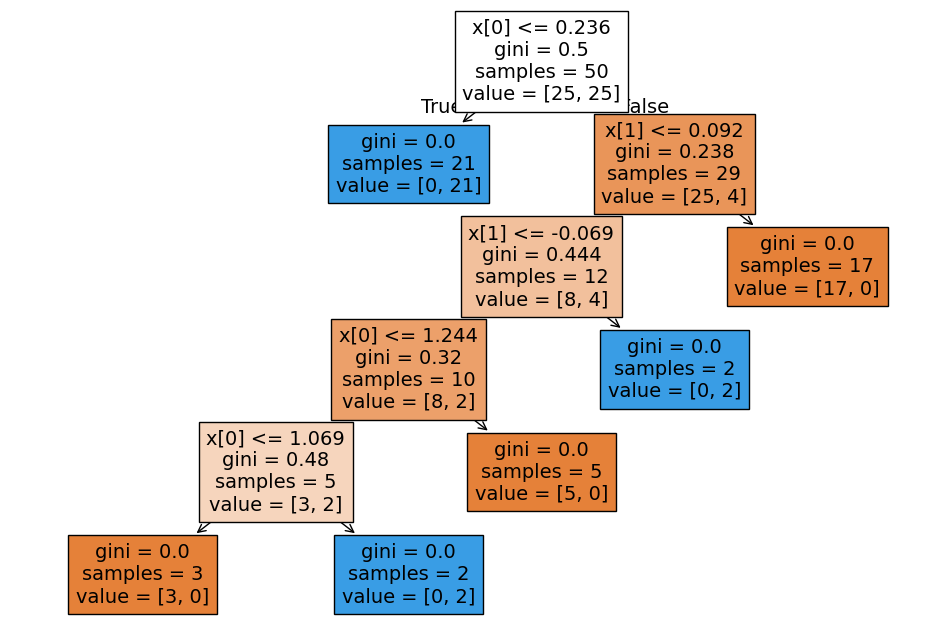

In [28]:
# Plot tree
plt.figure(figsize=(12,8))
plot_tree(clf1, filled=True)
plt.show()

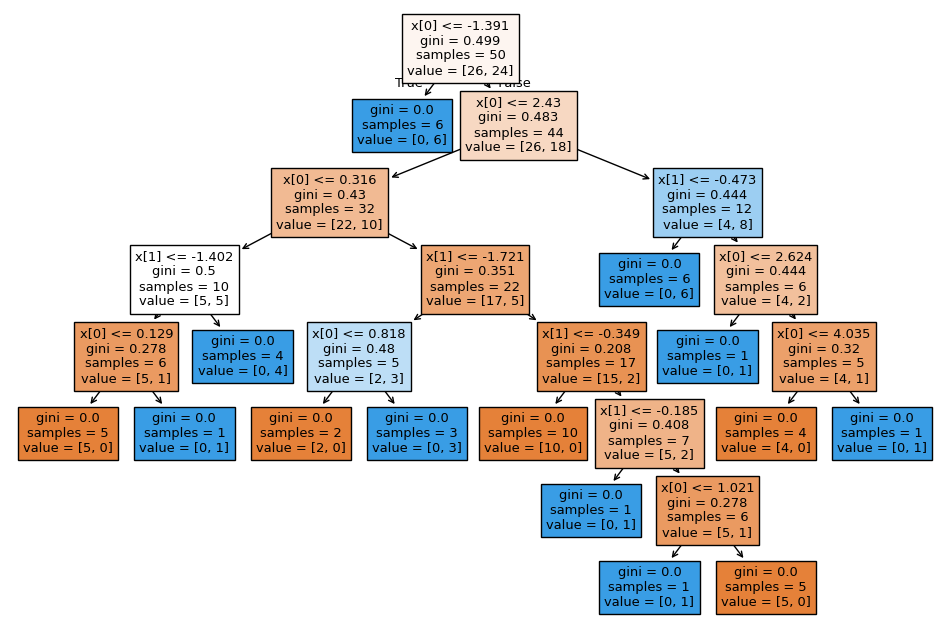

In [29]:
# Plot tree
plt.figure(figsize=(12,8))
plot_tree(clf2, filled=True)
plt.show()

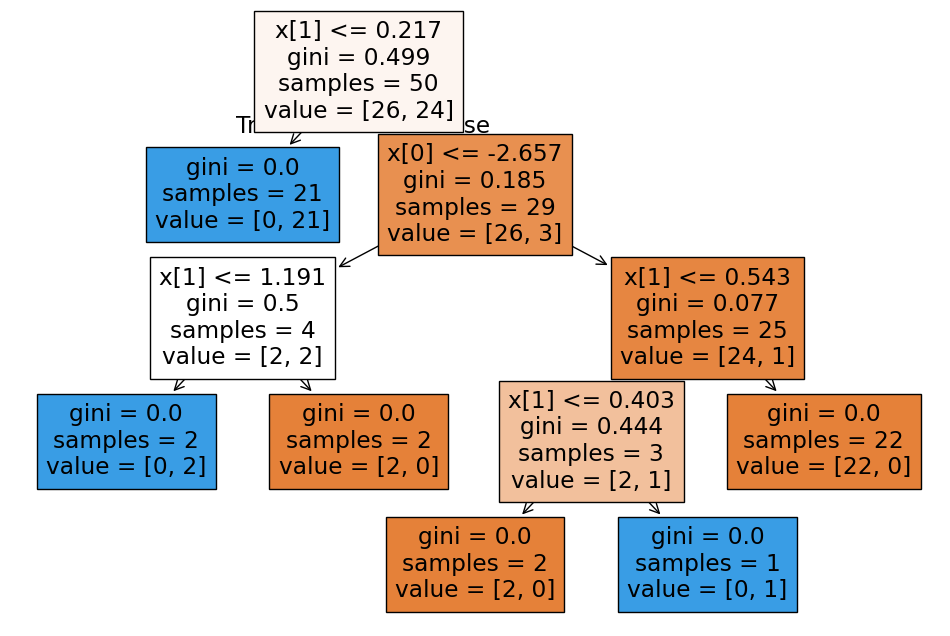

In [30]:
# Plot tree
plt.figure(figsize=(12,8))
plot_tree(clf3, filled=True)
plt.show()

In [31]:
df1.head()

,col4,col5,target
11,0.992968,1.039711,0
69,-0.117540,2.566190,1
14,-0.035378,-4.233013,1
87,-1.556725,0.850076,1
76,0.915677,0.640688,0


In [35]:
clf1.predict(np.array([0.992968,1.039711]).reshape(1,2))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [36]:
clf2.predict(np.array([0.992968,1.039711]).reshape(1,2))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [37]:
clf3.predict(np.array([0.992968,1.039711]).reshape(1,2))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [38]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
41,-1.484281,0.625992,-1.211145,0.646659,2.083348,0
95,0.552244,-1.244204,-0.227571,0.347299,-0.571779,1
42,2.322425,-2.771645,-0.854193,1.171771,-0.198446,1
37,1.889841,-1.530403,-0.546004,1.056652,1.359355,0
0,1.457434,-0.519318,0.355563,0.463960,-0.863662,1
68,1.220107,-0.827335,-1.711284,1.160471,0.037155,0
37,1.889841,-1.530403,-0.546004,1.056652,1.359355,0
33,0.024807,-2.404119,-2.269423,-2.460732,3.124773,1
93,1.918148,-0.496152,-0.344336,-2.153157,1.200214,1
68,1.220107,-0.827335,-1.711284,1.160471,0.037155,0
